# Практична робота №5: Шкали вимірювання і частотний розподіл

**Дисципліна:** «Аналіз даних та математичне моделювання»  
**Студент:** Хрустовський Павло  
**Група:** ІТ-42  
**Варіант:** 2 (м. Львів)  

**Мета:** класифікувати змінні власного набору за шкалою вимірювання, побудувати варіаційний ряд, частотну таблицю й гістограми та зв'язати міри положення зі шкалами вимірювання.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.float_format", lambda x: "%.2f" % x)


## 0. Приклад: наскрізна демонстрація

In [2]:
wait_min = pd.Series([2, 5, 3, 8, 4, 6, 3, 12, 5, 4, 7, 3, 5, 9, 4])  # неперервна
drinks = pd.Series([1, 2, 1, 0, 2, 1, 1, 3, 2, 1, 2, 1, 1, 0, 2])    # дискретна

# 1. Варіаційний ряд
print("Варіаційний ряд wait_min:", np.sort(wait_min.values))

# 2. Частотна таблиця для дискретної змінної (кількість напоїв)
freq = drinks.value_counts().sort_index()
rel = drinks.value_counts(normalize=True).sort_index() * 100
cum = freq.cumsum()
demo_table = pd.DataFrame({"абсолютна": freq, "відносна_%": rel.round(1), "накопичена": cum})
display(demo_table)


Варіаційний ряд wait_min: [ 2  3  3  3  4  4  4  5  5  5  6  7  8  9 12]


,абсолютна,відносна_%,накопичена
0,2,13.30,2
1,7,46.70,9
2,5,33.30,14
3,1,6.70,15


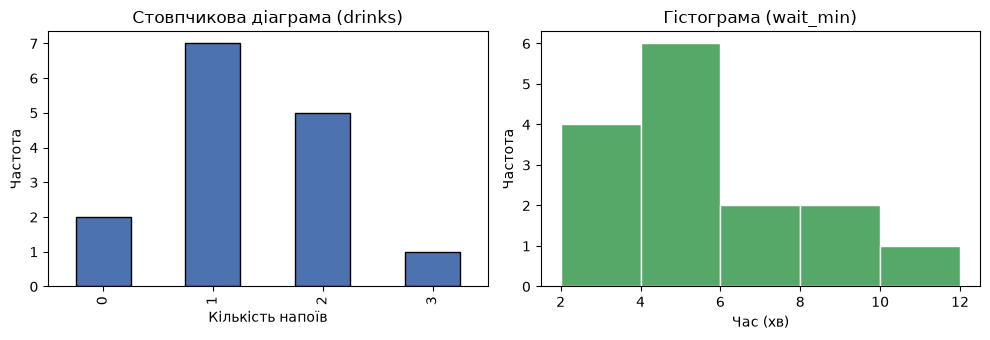

Середнє: 5.33, Медіана: 5.00, Мода: 3
Квантилі [0.25, 0.5, 0.75]: {0.25: 3.5, 0.5: 5.0, 0.75: 6.5}


In [3]:
# 3. Стовпчикова діаграма та 4. Гістограма
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))

drinks.value_counts().sort_index().plot(kind="bar", ax=axes[0], color="#4C72B0", edgecolor="black")
axes[0].set_title("Стовпчикова діаграма (drinks)")
axes[0].set_xlabel("Кількість напоїв")
axes[0].set_ylabel("Частота")

axes[1].hist(wait_min, bins=5, edgecolor="white", color="#55A868")
axes[1].set_title("Гістограма (wait_min)")
axes[1].set_xlabel("Час (хв)")
axes[1].set_ylabel("Частота")

plt.tight_layout()
plt.show()

# 5. Міри положення та квантилі
print(f"Середнє: {wait_min.mean():.2f}, Медіана: {wait_min.median():.2f}, Мода: {wait_min.mode()[0]}")
print("Квантилі [0.25, 0.5, 0.75]:", wait_min.quantile([0.25, 0.5, 0.75]).to_dict())


## Дані Варіанта 2 (Львів)

In [4]:
months = ["Січ", "Лют", "Бер", "Кві", "Тра", "Чер", "Лип", "Сер", "Вер", "Жов", "Лис", "Гру"]
precip = [40, 38, 40, 55, 80, 95, 100, 85, 55, 45, 48, 42]

df = pd.DataFrame({
    "місто": ["Львів"] * 12,
    "номер_місяця": list(range(1, 13)),
    "місяць": months,
    "опади_мм": precip
})
display(df)


,місто,номер_місяця,місяць,опади_мм
0,Львів,1,Січ,40
1,Львів,2,Лют,38
2,Львів,3,Бер,40
3,Львів,4,Кві,55
4,Львів,5,Тра,80
5,Львів,6,Чер,95
6,Львів,7,Лип,100
7,Львів,8,Сер,85
8,Львів,9,Вер,55
9,Львів,10,Жов,45


## Завдання 1. Класифікація змінних за шкалою вимірювання

1. **`місто` — Номінальна шкала:** якісна текстова категорія. Немає природного порядку та відстаней, можлива лише перевірка на рівність ($A = B$). Допустима міра положення — **лише мода**.
2. **`номер_місяця` (1–12) — Порядкова / інтервальна (циклічна) шкала:**
   - *Аргумент за інтервальну:* місяці йдуть у строгому хронологічному порядку, календарні проміжки між ними майже однакові (~30 днів), тому різниця часових інтервалів має сенс.
   - *Аргумент за порядкову:* немає природного нуля («нульового місяця» не існує), операції множення беззмістовні (серпень 8 не є «вдвічі більшим» за квітень 4), а час циклічний ($12 \to 1$).
   - Допустимі міри положення — **мода і медіана** (середнє некоректне, оскільки не враховує циклічності).
3. **`опади_мм` — Відносна шкала:** неперервна кількісна величина з **природним нулем** (0 мм = повна відсутність опадів). Допустимі операції додавання, множення й відношення. Коректні **всі міри: мода, медіана, середнє арифметичне** та квантилі.


## Завдання 2. Варіаційний ряд і частотна таблиця

In [5]:
# Варіаційний ряд
var_series = np.sort(df["опади_мм"].values)
print("Варіаційний ряд опадів (мм):", var_series)

# Розбиття на 4 рівномірні інтервали
# min=38, max=100, step=(100-38)/4 = 15.5
bins_4 = [38.0, 53.5, 69.0, 84.5, 100.0]
cats = pd.cut(df["опади_мм"], bins=bins_4, include_lowest=True)

f_abs = cats.value_counts().sort_index()
f_rel = (cats.value_counts(normalize=True).sort_index() * 100).round(1)
c_abs = f_abs.cumsum()
c_rel = f_rel.cumsum().round(1)

table_freq = pd.DataFrame({
    "Інтервал": ["[38.0, 53.5]", "(53.5, 69.0]", "(69.0, 84.5]", "(84.5, 100.0]"],
    "Абсолютна частота": f_abs.values,
    "Відносна частота, %": f_rel.values,
    "Накопичена абсолютна": c_abs.values,
    "Накопичена відносна, %": c_rel.values
})
display(table_freq)


Варіаційний ряд опадів (мм): [ 38  40  40  42  45  48  55  55  80  85  95 100]


,Інтервал,Абсолютна частота,"Відносна частота, %",Накопичена абсолютна,"Накопичена відносна, %"
0,"[38.0, 53.5]",6,50.00,6,50.00
1,"(53.5, 69.0]",2,16.70,8,66.70
2,"(69.0, 84.5]",1,8.30,9,75.00
3,"(84.5, 100.0]",3,25.00,12,100.00


**Висновок до Завдання 2:**  
На межі третього інтервалу ($84.5$ мм) накопичена частота становить **$9$ місяців**, тобто **$75.0\%$**. Це означає, що у 75% місяців року у Львові випадає не більше $84.5$ мм опадів (помірно-сухий сезон), і лише у 3 літніх місяцях ($25\%$) опади перевищують цю межу.


## Завдання 3. Гістограма

n = 12 | Правило √n: 3.46 (~3-4) | Правило Стерджеса: 4.58 (~4-5)


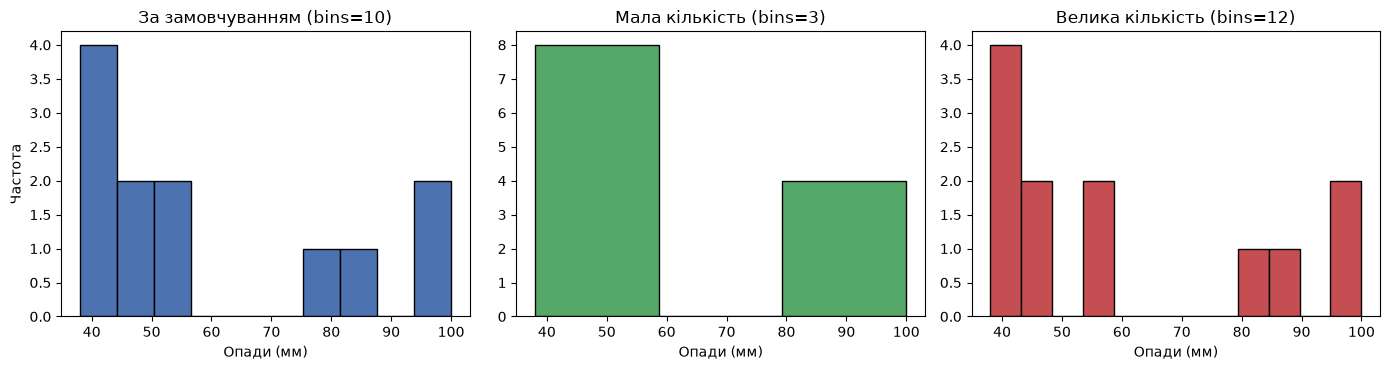

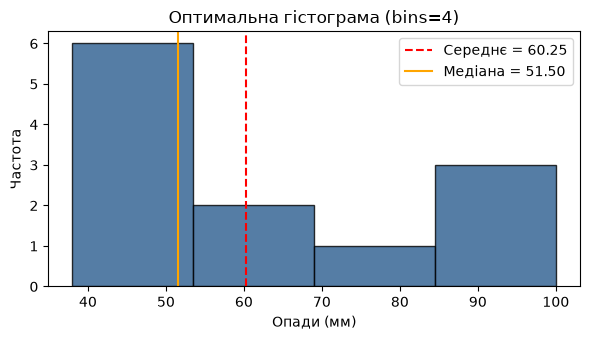

In [6]:
# Кількість інтервалів за правилами
n = len(df)
k_sqrt = np.sqrt(n)
k_sturges = 1 + np.log2(n)
print(f"n = {n} | Правило √n: {k_sqrt:.2f} (~3-4) | Правило Стерджеса: {k_sturges:.2f} (~4-5)")

# Порівняння трьох гістограм
fig, axes = plt.subplots(1, 3, figsize=(14, 3.8))

axes[0].hist(df["опади_мм"], bins=10, edgecolor="black", color="#4C72B0")
axes[0].set_title("За замовчуванням (bins=10)")
axes[0].set_xlabel("Опади (мм)")
axes[0].set_ylabel("Частота")

axes[1].hist(df["опади_мм"], bins=3, edgecolor="black", color="#55A868")
axes[1].set_title("Мала кількість (bins=3)")
axes[1].set_xlabel("Опади (мм)")

axes[2].hist(df["опади_мм"], bins=12, edgecolor="black", color="#C44E52")
axes[2].set_title("Велика кількість (bins=12)")
axes[2].set_xlabel("Опади (мм)")

plt.tight_layout()
plt.show()

# Оптимальна гістограма (bins=4)
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.hist(df["опади_мм"], bins=4, edgecolor="black", color="#2b5c8f", alpha=0.8)
ax.axvline(df["опади_мм"].mean(), color="red", linestyle="--", label=f"Середнє = {df['опади_мм'].mean():.2f}")
ax.axvline(df["опади_мм"].median(), color="orange", linestyle="-", label=f"Медіана = {df['опади_мм'].median():.2f}")
ax.set_title("Оптимальна гістограма (bins=4)")
ax.set_xlabel("Опади (мм)")
ax.set_ylabel("Частота")
ax.legend()
plt.tight_layout()
plt.show()


**Висновок до Завдання 3:**  
- `bins=3` надмірно згладжує дані (underfitting), об'єднуючи половину місяців в один стовпець.  
- `bins=10` та `bins=12` надмірно подрібнюють малу вибірку ($n=12$), створюючи порожні проміжки з частотою 0.  
- Найкраще форму розподілу показує гістограма з **$4$ інтервалами** (відповідає правилам $\sqrt{n}$ та Стерджеса): вона чітко відображає правосторонню асиметрію без зайвого шуму.


## Завдання 4. Міри положення й квантилі

In [7]:
mean_val = df["опади_мм"].mean()
median_val = df["опади_мм"].median()
mode_val = df["опади_мм"].mode().tolist()
q1 = df["опади_мм"].quantile(0.25)
q3 = df["опади_мм"].quantile(0.75)

res = pd.DataFrame({
    "Показник": ["Середнє", "Медіана", "Мода", "Q1 (25%)", "Q3 (75%)", "IQR"],
    "Значення": [f"{mean_val:.2f}", f"{median_val:.2f}", f"{mode_val}", f"{q1:.2f}", f"{q3:.2f}", f"{q3-q1:.2f}"]
})
display(res)


,Показник,Значення
0,Середнє,60.25
1,Медіана,51.50
2,Мода,"[40, 55]"
3,Q1 (25%),41.50
4,Q3 (75%),81.25
5,IQR,39.75


**Висновок до Завдання 4:**  
Середнє ($60.25$ мм) більше за медіану ($51.50$ мм) на $+8.75$ мм ($+17\%$). Співвідношення $\bar{x} > Me$ вказує на **правосторонню (позитивну) асиметрію**: більшість місяців року є помірно-сухими ($38$–$48$ мм), проте кілька дощових літніх місяців (червень — 95, липень — 100, серпень — 85 мм) тягнуть середнє вгору. Медіана є робастною і точніше показує типовий місяць.


## Завдання 5. Зв'язок зі шкалою вимірювання

- **Кількість опадів (відносна шкала):** має природний нуль (0 мм) та метричну одиницю. Це дозволяє знаходити як порядок ($x_i < x_j$ для медіани і квантилів) та моду, так і сумувати значення (для середнього $\frac{1}{n}\sum x_i$).
- **Місто (номінальна шкала):** суто категоріальна назва без порядку й метрики. Числове кодування є штучним, а його середнє не має змісту. Тому для номінальної шкали допустима **лише мода**.


## Відповіді на контрольні запитання

1. **Чому середнє арифметичне некоректне для номінальної змінної "місто", навіть якщо закодувати міста числами?**  
   Числові коди міст є довільними мітками. При іншій нумерації середнє зміниться, тобто воно неінваріантне щодо допустимих перетворень. Назви міст не мають фізичного порядку чи відстаней.

2. **Чому "номер місяця" — приклад неоднозначної класифікації шкали?**  
   З одного боку, інтервали часу між місяцями майже однакові (~30 днів), що наближає змінну до інтервальної шкали. З іншого боку, немає абсолютного нуля («нульового місяця»), множення номерів не має сенсу, а час циклічний (після 12 настає 1).

3. **Чому для опадів потрібна гістограма з інтервалами, а не стовпчикова діаграма за значеннями?**  
   Опади — неперервна величина, більшість значень якої унікальні (10 із 12). Стовпчикова діаграма за окремими числами утворить неефективну гребінку висотою 1 та 2. Гістограма групує близькі значення в інтервали і наочно показує щільність та форму розподілу.

4. **Що означає накопичена частота на межі третього інтервалу?**  
   Вона показує, що у **$75\%$ місяців року (9 із 12)** кількість опадів не перевищує $84.5$ мм. Лише у 25% місяців (3 літні місяці) опади перевищують цю межу.
